In [18]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import warnings

import umap

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, NMF, KernelPCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.manifold import TSNE

warnings.filterwarnings("ignore")

In [19]:
SEED = 42
PLOT_DPI = 50

DATA_FILE = "../../datasets/Skoltech_Anomaly_Benchmark/preprocessed_skab_dataset.csv"

In [20]:
dataframe = pd.read_csv(DATA_FILE)
dataframe.set_index(pd.to_datetime(dataframe.datetime), drop=True, inplace=True)
dataframe.drop(columns=["datetime"], inplace=True)
dataframe

,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,anomaly,description
datetime,,,,,,,,,,
2020-02-08 13:30:47,0.202394,0.275154,2.169750,0.382638,90.6454,26.8508,238.852,122.6640,0.0,No Anomaly
2020-02-08 13:30:48,0.203153,0.277857,2.079990,-0.273216,90.7978,26.8639,227.943,122.3380,0.0,No Anomaly
2020-02-08 13:30:49,0.203153,0.277857,2.079990,-0.273216,90.7978,26.8639,227.943,122.3380,0.0,No Anomaly
2020-02-08 13:30:50,0.202054,0.275790,2.525770,0.382638,90.7730,26.8603,223.486,121.3380,0.0,No Anomaly
2020-02-08 13:30:51,0.203595,0.278101,2.497420,0.054711,90.8424,26.8616,244.904,121.6640,0.0,No Anomaly
...,...,...,...,...,...,...,...,...,...,...
2020-03-09 17:14:05,0.027067,0.038430,0.988875,0.054711,69.6731,24.1046,230.729,32.9562,0.0,No Anomaly
2020-03-09 17:14:06,0.027067,0.038430,0.988875,0.054711,69.6731,24.1046,230.729,32.9562,0.0,No Anomaly
2020-03-09 17:14:07,0.027582,0.038836,0.588439,0.054711,69.6959,24.1020,233.443,32.0000,0.0,No Anomaly


In [21]:
dataframe_X = dataframe.drop(columns=["anomaly", "description"])
dataframe_y = dataframe[["anomaly"]]

In [22]:
dataframe_X

,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS
datetime,,,,,,,,
2020-02-08 13:30:47,0.202394,0.275154,2.169750,0.382638,90.6454,26.8508,238.852,122.6640
2020-02-08 13:30:48,0.203153,0.277857,2.079990,-0.273216,90.7978,26.8639,227.943,122.3380
2020-02-08 13:30:49,0.203153,0.277857,2.079990,-0.273216,90.7978,26.8639,227.943,122.3380
2020-02-08 13:30:50,0.202054,0.275790,2.525770,0.382638,90.7730,26.8603,223.486,121.3380
2020-02-08 13:30:51,0.203595,0.278101,2.497420,0.054711,90.8424,26.8616,244.904,121.6640
...,...,...,...,...,...,...,...,...
2020-03-09 17:14:05,0.027067,0.038430,0.988875,0.054711,69.6731,24.1046,230.729,32.9562
2020-03-09 17:14:06,0.027067,0.038430,0.988875,0.054711,69.6731,24.1046,230.729,32.9562
2020-03-09 17:14:07,0.027582,0.038836,0.588439,0.054711,69.6959,24.1020,233.443,32.0000


In [23]:
dataframe_y.anomaly.value_counts()

anomaly
0.0     35160
12.0     6664
13.0     1682
11.0     1437
6.0       619
7.0       475
1.0       429
8.0       424
4.0       422
2.0       421
5.0       421
9.0       367
3.0       363
10.0      318
Name: count, dtype: int64

In [24]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(dataframe_X.to_numpy())
X_scaled

array([[ 0.5779368 ,  0.77918339,  0.64577214, ...,  0.12739321,
         0.84717893,  1.04416841],
       [ 0.58391141,  0.79783152,  0.5334729 , ...,  0.13251625,
        -0.15680658,  1.03701398],
       [ 0.58391141,  0.79783152,  0.5334729 , ...,  0.13251625,
        -0.15680658,  1.03701398],
       ...,
       [-0.79812333, -0.85118592, -1.33261506, ..., -0.9475845 ,
         0.34937367, -0.94555392],
       [-0.7995111 , -0.85603526, -0.8305551 , ..., -0.9475845 ,
         0.85435749, -0.94555392],
       [-0.80190645, -0.84391295, -1.37053983, ..., -0.94946165,
        -0.91975825, -0.94555392]], shape=(49202, 8))

## Linear Dimensionality Reduction Techniques

### Principal Component Analysis (PCA)

In [25]:
print("\n--- Applying PCA ---")
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("PCA reduced data shape:", X_pca.shape)
dataframe_pca = pd.DataFrame(X_pca, columns=["Principal_Component_1", "Principal_Component_2"])
dataframe_pca = dataframe_pca.assign(anomaly=dataframe.anomaly.values, description=dataframe.description.values)
dataframe_pca


--- Applying PCA ---
PCA reduced data shape: (49202, 2)


,Principal_Component_1,Principal_Component_2,anomaly,description
0,1.834479,0.882588,0.0,No Anomaly
1,1.713671,-0.083354,0.0,No Anomaly
2,1.713671,-0.083354,0.0,No Anomaly
3,2.061129,-0.396891,0.0,No Anomaly
4,1.924605,1.532054,0.0,No Anomaly
...,...,...,...,...
49197,-2.194597,0.022538,0.0,No Anomaly
49198,-2.194597,0.022538,0.0,No Anomaly
49199,-2.409342,0.156216,0.0,No Anomaly
49200,-2.299055,0.776456,0.0,No Anomaly


In [26]:
def plot_pca(df, title="PCA (2 Components)"):
    plt.figure(figsize=(20, 6), dpi=PLOT_DPI)
    scatter = sns.scatterplot(
                        data=df, 
                        x=df.Principal_Component_1,
                        y=df.Principal_Component_2,
                        hue="description", style="description", 
                        edgecolor="black", zorder=5, alpha=0.7,
                        palette="deep", s=100, legend="full"
    )
    sns.move_legend(
                        scatter, "lower center",
                        bbox_to_anchor=(.5, 1.1),
                        ncol=5, title="Description", frameon=True,
    )
    plt.grid(True)
    plt.title(title, fontsize=20)
    plt.show()

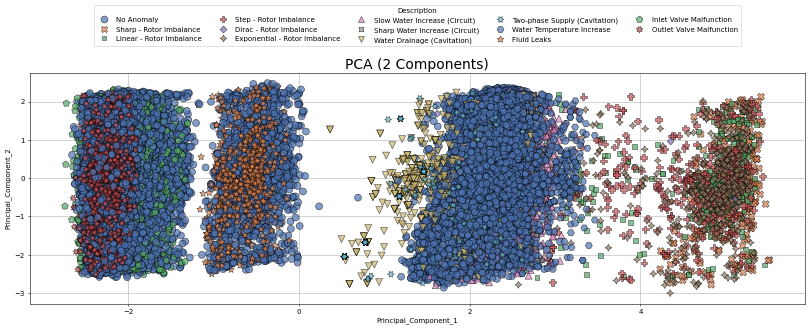

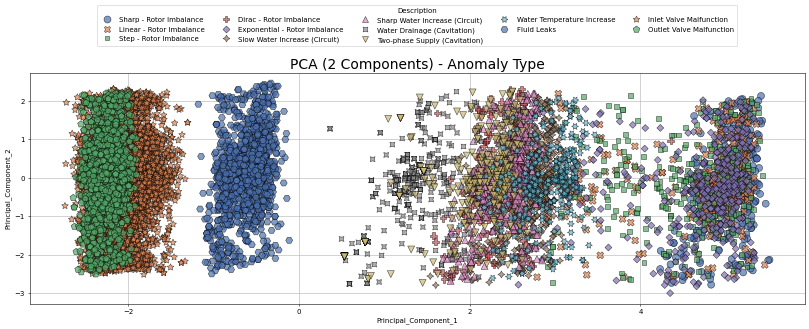

In [27]:
plot_pca(dataframe_pca)
plot_pca(dataframe_pca.iloc[np.where(dataframe_pca.anomaly!=0.0)], title="PCA (2 Components) - Anomaly Type")

### Linear Discriminant Analysis (LDA)

In [28]:
print("\n--- Applying LDA ---")
lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(X_scaled, dataframe_y.to_numpy().ravel())

print("LDA reduced data shape:", X_lda.shape)
dataframe_lda = pd.DataFrame(X_lda, columns=["Linear_Discriminant_1", "Linear_Discriminant_2"])
dataframe_lda = dataframe_lda.assign(anomaly=dataframe.anomaly.values, description=dataframe.description.values)
dataframe_lda


--- Applying LDA ---
LDA reduced data shape: (49202, 2)


,Linear_Discriminant_1,Linear_Discriminant_2,anomaly,description
0,0.387784,-0.865302,0.0,No Anomaly
1,0.379192,-1.194855,0.0,No Anomaly
2,0.379192,-1.194855,0.0,No Anomaly
3,0.546689,-1.228102,0.0,No Anomaly
4,0.373486,-1.210664,0.0,No Anomaly
...,...,...,...,...
49197,0.511630,1.137725,0.0,No Anomaly
49198,0.511630,1.137725,0.0,No Anomaly
49199,0.280105,1.208793,0.0,No Anomaly
49200,0.378279,1.177354,0.0,No Anomaly


In [29]:
def plot_lda(df, title="LDA (2 Components)"):
    plt.figure(figsize=(20, 6), dpi=PLOT_DPI)
    scatter = sns.scatterplot(
                        data=df, 
                        x=df.Linear_Discriminant_1,
                        y=df.Linear_Discriminant_2,
                        hue="description", style="description", 
                        edgecolor="black", zorder=5, alpha=0.7,
                        palette="deep", s=100, legend="full"
    )
    sns.move_legend(
                        scatter, "lower center",
                        bbox_to_anchor=(.5, 1.1),
                        ncol=5, title="Description", frameon=True,
    )
    plt.grid(True)
    plt.title(title, fontsize=20)
    plt.show()

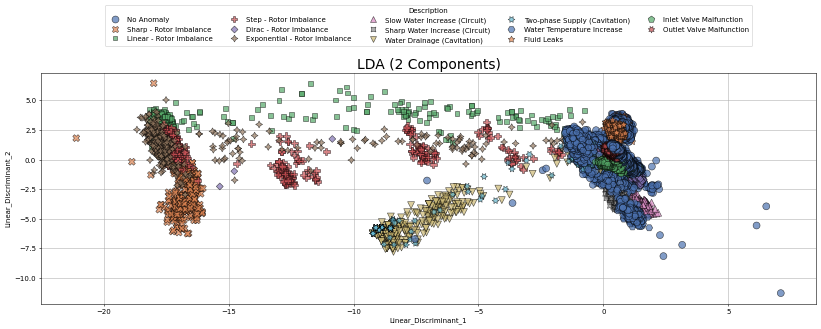

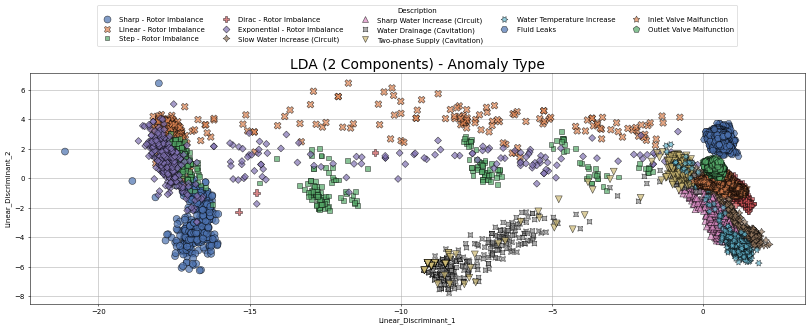

In [30]:
plot_lda(dataframe_lda)
plot_lda(dataframe_lda.iloc[np.where(dataframe_lda.anomaly!=0.0)], title="LDA (2 Components) - Anomaly Type")

### Non-Negative Matrix Factorization (NMF)

In [31]:
print("\n--- Applying NMF ---")
# For NMF, the input data must be non-negative.
X_nmf_positive = dataframe_X.to_numpy() - dataframe_X.to_numpy().min() # Simple way to make it non-negative for demo
nmf = NMF(n_components=2, init='random', random_state=42, max_iter=500)
X_nmf = nmf.fit_transform(X_nmf_positive)

print("NMF reduced data shape:", X_nmf.shape)
dataframe_nmf = pd.DataFrame(X_nmf, columns=["NMF_Component_1", "NMF_Component_2"])
dataframe_nmf = dataframe_nmf.assign(anomaly=dataframe.anomaly.values, description=dataframe.description.values)
dataframe_nmf


--- Applying NMF ---
NMF reduced data shape: (49202, 2)


,NMF_Component_1,NMF_Component_2,anomaly,description
0,14.770381,2.934412,0.0,No Anomaly
1,14.807092,2.126416,0.0,No Anomaly
2,14.807092,2.126416,0.0,No Anomaly
3,14.721431,1.904660,0.0,No Anomaly
4,14.620797,3.528903,0.0,No Anomaly
...,...,...,...,...
49197,4.053333,13.584020,0.0,No Anomaly
49198,4.053333,13.584020,0.0,No Anomaly
49199,3.925560,13.915065,0.0,No Anomaly
49200,3.889064,14.341275,0.0,No Anomaly


In [32]:
def plot_nmf(df, title="NMF (2 Components)"):
    plt.figure(figsize=(20, 6), dpi=PLOT_DPI)
    scatter = sns.scatterplot(
                        data=df, 
                        x=df.NMF_Component_1,
                        y=df.NMF_Component_2,
                        hue="description", style="description", 
                        edgecolor="black", zorder=5, alpha=0.7,
                        palette="deep", s=100, legend="full"
    )
    sns.move_legend(
                        scatter, "lower center",
                        bbox_to_anchor=(.5, 1.1),
                        ncol=5, title="Description", frameon=True,
    )
    plt.grid(True)
    plt.title(title, fontsize=20)
    plt.show()

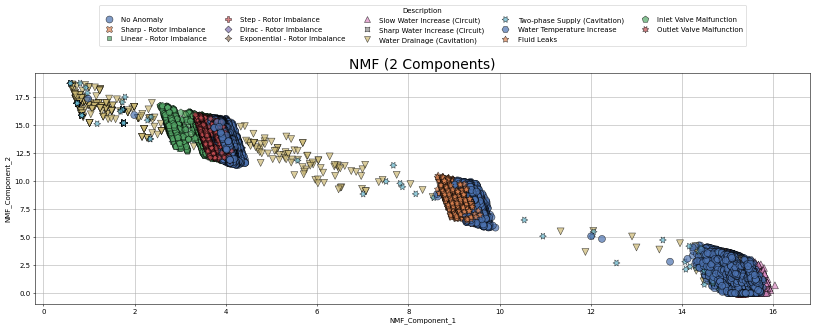

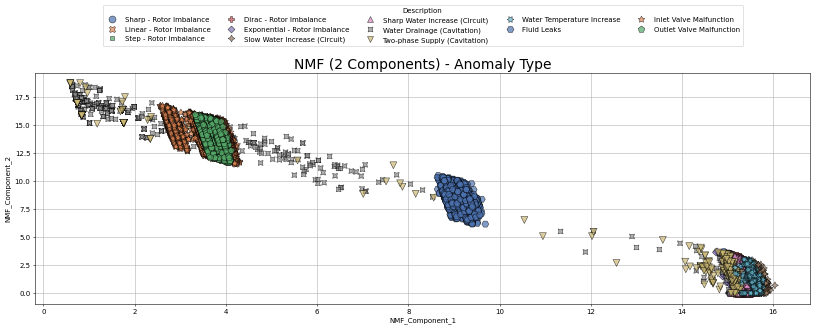

In [33]:
plot_nmf(dataframe_nmf)
plot_nmf(dataframe_nmf.iloc[np.where(dataframe_nmf.anomaly!=0.0)], title="NMF (2 Components) - Anomaly Type")

## Non-linear Dimensionality Reduction Techniques

### t-Distributed Stochastic Neighbor Embedding (t-SNE)

In [34]:
print("\n--- Applying t-SNE ---")
tsne = TSNE(n_components=2, random_state=42, perplexity=50, n_jobs=5)
X_tsne = tsne.fit_transform(X_scaled)

print("t-SNE reduced data shape:", X_tsne.shape)
dataframe_tsne = pd.DataFrame(X_tsne, columns=["tSNE_Component_1", "tSNE_Component_2"])
dataframe_tsne = dataframe_tsne.assign(anomaly=dataframe.anomaly.values, description=dataframe.description.values)
dataframe_tsne


--- Applying t-SNE ---
t-SNE reduced data shape: (49202, 2)


,tSNE_Component_1,tSNE_Component_2,anomaly,description
0,115.573830,28.037016,0.0,No Anomaly
1,1.267185,-54.777241,0.0,No Anomaly
2,1.267159,-54.777260,0.0,No Anomaly
3,126.652283,17.076796,0.0,No Anomaly
4,62.048717,69.633873,0.0,No Anomaly
...,...,...,...,...
49197,-94.732903,-3.981990,0.0,No Anomaly
49198,-94.732903,-3.981990,0.0,No Anomaly
49199,-116.127815,9.331303,0.0,No Anomaly
49200,-29.206488,43.713013,0.0,No Anomaly


In [35]:
def plot_tsne(df, title="tSNE (2 Components)"):
    plt.figure(figsize=(12, 12), dpi=PLOT_DPI)
    scatter = sns.scatterplot(
                        data=df, 
                        x=df.tSNE_Component_1,
                        y=df.tSNE_Component_2,
                        hue="description", style="description", 
                        edgecolor="black", zorder=5, alpha=0.7,
                        palette="deep", s=100, legend="full"
    )
    sns.move_legend(
                        scatter, "lower center",
                        bbox_to_anchor=(.5, 1.1),
                        ncol=5, title="Description", frameon=True,
    )
    plt.grid(True)
    plt.title(title, fontsize=20)
    plt.show()

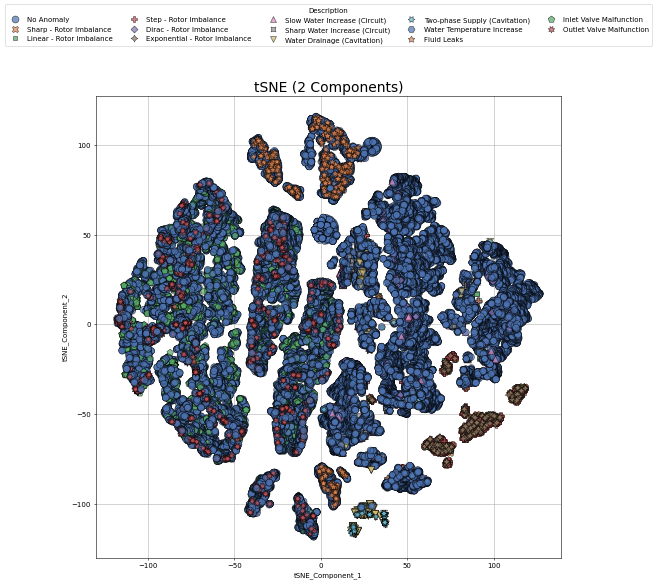

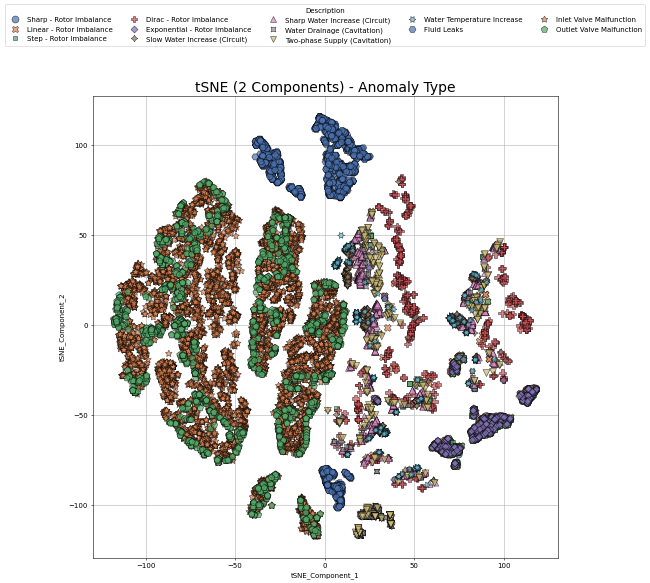

In [36]:
plot_tsne(dataframe_tsne)
plot_tsne(dataframe_tsne.iloc[np.where(dataframe_tsne.anomaly!=0.0)], title="tSNE (2 Components) - Anomaly Type")

### Uniform Manifold Approximation and Projection (UMAP)

In [37]:
print("\n--- Applying UMAP ---")
reducer = umap.UMAP(n_components=2, random_state=42)
X_umap = reducer.fit_transform(X_scaled)

print("UMAP reduced data shape:", X_umap.shape)
dataframe_umap = pd.DataFrame(X_umap, columns=["UMAP_Component_1", "UMAP_Component_2"])
dataframe_umap = dataframe_umap.assign(anomaly=dataframe.anomaly.values, description=dataframe.description.values)
dataframe_umap


--- Applying UMAP ---
UMAP reduced data shape: (49202, 2)


,UMAP_Component_1,UMAP_Component_2,anomaly,description
0,-3.219496,17.375263,0.0,No Anomaly
1,-2.444361,-3.604455,0.0,No Anomaly
2,-2.452022,-3.609006,0.0,No Anomaly
3,-5.150447,16.084618,0.0,No Anomaly
4,-8.914398,1.614077,0.0,No Anomaly
...,...,...,...,...
49197,3.120397,5.129667,0.0,No Anomaly
49198,3.122471,5.147973,0.0,No Anomaly
49199,4.192226,4.453987,0.0,No Anomaly
49200,17.456064,1.727112,0.0,No Anomaly


In [38]:
def plot_umap(df, title="UMAP (2 Components)"):
    plt.figure(figsize=(12, 12), dpi=PLOT_DPI)
    scatter = sns.scatterplot(
                        data=df, 
                        x=df.UMAP_Component_1,
                        y=df.UMAP_Component_2,
                        hue="description", style="description", 
                        edgecolor="black", zorder=5, alpha=0.7,
                        palette="deep", s=100, legend="full"
    )
    sns.move_legend(
                        scatter, "lower center",
                        bbox_to_anchor=(.5, 1.1),
                        ncol=5, title="Description", frameon=True,
    )
    plt.grid(True)
    plt.title(title, fontsize=20)
    plt.show()

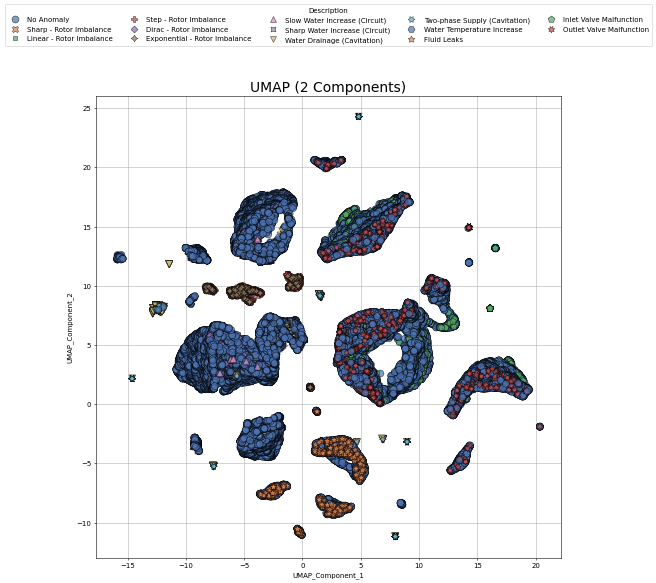

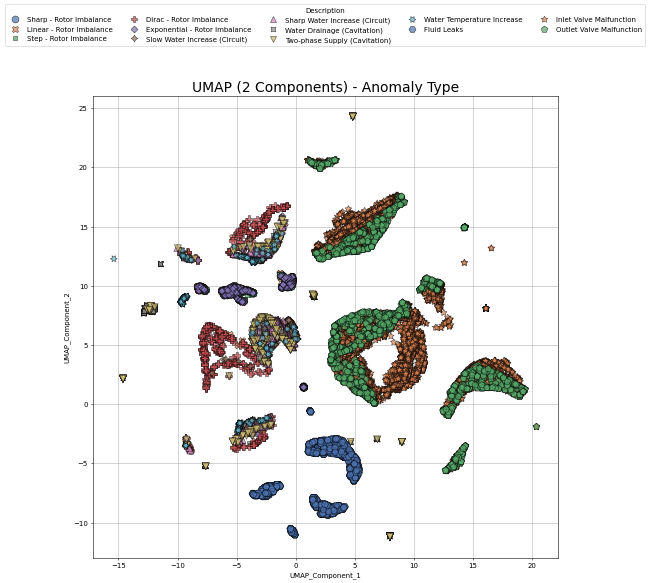

In [39]:
plot_umap(dataframe_umap)
plot_umap(dataframe_umap.iloc[np.where(dataframe_umap.anomaly!=0.0)], title="UMAP (2 Components) - Anomaly Type")

### Kernel Principal Component Analysis (KPCA)

In [40]:
print("\n--- Applying Kernel PCA ---")
kpca = KernelPCA(n_components=2, kernel="rbf", gamma=15)
X_kpca = kpca.fit_transform(X_scaled)

print("Kernel PCA reduced data shape:", X_kpca.shape)
dataframe_kpca = pd.DataFrame(X_pca, columns=["K_Principal_Component_1", "K_Principal_Component_2"])
dataframe_kpca = dataframe_kpca.assign(anomaly=dataframe.anomaly.values, description=dataframe.description.values)
dataframe_kpca


--- Applying Kernel PCA ---
Kernel PCA reduced data shape: (49202, 2)


,K_Principal_Component_1,K_Principal_Component_2,anomaly,description
0,1.834479,0.882588,0.0,No Anomaly
1,1.713671,-0.083354,0.0,No Anomaly
2,1.713671,-0.083354,0.0,No Anomaly
3,2.061129,-0.396891,0.0,No Anomaly
4,1.924605,1.532054,0.0,No Anomaly
...,...,...,...,...
49197,-2.194597,0.022538,0.0,No Anomaly
49198,-2.194597,0.022538,0.0,No Anomaly
49199,-2.409342,0.156216,0.0,No Anomaly
49200,-2.299055,0.776456,0.0,No Anomaly


In [41]:
def plot_kpca(df, title="KPCA (2 Components)"):
    plt.figure(figsize=(20, 6), dpi=PLOT_DPI)
    scatter = sns.scatterplot(
                        data=df, 
                        x=df.K_Principal_Component_1,
                        y=df.K_Principal_Component_2,
                        hue="description", style="description", 
                        edgecolor="black", zorder=5, alpha=0.7,
                        palette="deep", s=100, legend="full"
    )
    sns.move_legend(
                        scatter, "lower center",
                        bbox_to_anchor=(.5, 1.1),
                        ncol=5, title="Description", frameon=True,
    )
    plt.grid(True)
    plt.title(title, fontsize=20)
    plt.show()

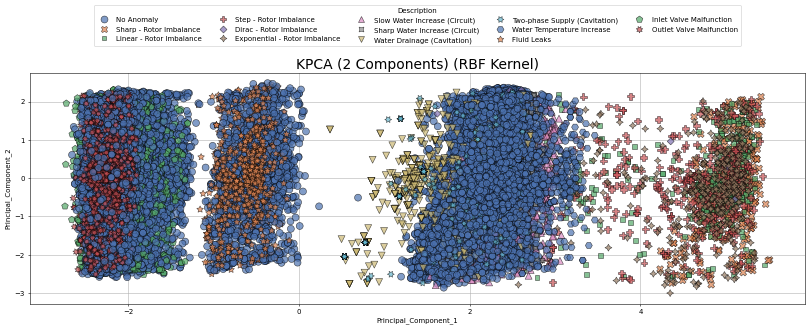

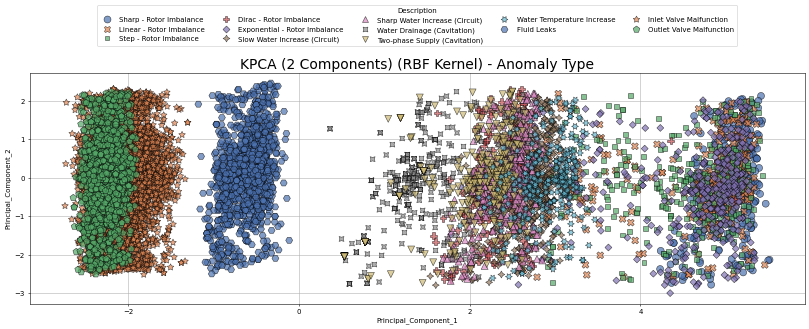

In [42]:
plot_pca(dataframe_pca, title="KPCA (2 Components) (RBF Kernel)")
plot_pca(dataframe_pca.iloc[np.where(dataframe_pca.anomaly!=0.0)], title="KPCA (2 Components) (RBF Kernel) - Anomaly Type")

**Explanation and Key Considerations:**

1.  **PCA (Principal Component Analysis):**

      * `PCA(n_components=2)`: Reduces the data to 2 principal components.
      * `fit_transform()`: Learns the principal components from the data and then transforms the data.
      * `explained_variance_ratio_`: Shows the proportion of variance explained by each principal component. This helps in deciding the number of components to keep.

2.  **LDA (Linear Discriminant Analysis):**

      * `LinearDiscriminantAnalysis(n_components=2)`: Reduces the data to 2 linear discriminants.
      * **Requires `y` (class labels)** in `fit_transform()`.
      * The maximum number of components for LDA is `n_classes - 1`.

3.  **NMF (Non-Negative Matrix Factorization):**

      * `NMF(n_components=2, init='random', random_state=42)`: Reduces the data to 2 non-negative components.
      * **Important:** Input data to NMF *must* be non-negative. I've included a simple `X_general - X_general.min()` to achieve this for demonstration. In real-world scenarios, ensure your data is naturally non-negative (e.g., pixel intensities, word counts).
      * `init`: How the initial matrices are chosen. 'random' is common, 'nndsvd' is more robust for sparse data.

4.  **t-SNE (t-Distributed Stochastic Neighbor Embedding):**

      * `TSNE(n_components=2, perplexity=30, n_iter=1000)`:
          * `perplexity`: Relates to the number of nearest neighbors used. A common range is 5-50. Higher values consider more global structure.
          * `n_iter`: Number of iterations for optimization. t-SNE is an iterative, optimization-based algorithm.
      * **Primarily for visualization:** It's generally not used as a preprocessing step for other models due to its non-linear and non-deterministic nature.
      * Computationally intensive for very large datasets.

5.  **UMAP (Uniform Manifold Approximation and Projection):**

      * `umap.UMAP(n_components=2, random_state=42)`:
          * `n_neighbors`: Controls the balance between local and global structure in the embedding. Smaller values emphasize local structure, larger values emphasize global structure.
          * `min_dist`: Controls how tightly the embedded points are clustered together. Smaller values lead to tighter clusters.
      * Often preferred over t-SNE for larger datasets due to better speed and better preservation of global structure.

6.  **KPCA (Kernel PCA):**

      * `KernelPCA(n_components=2, kernel="rbf", gamma=15)`:
          * `kernel`: Specifies the kernel function ('linear', 'poly', 'rbf', 'sigmoid', 'cosine'). 'rbf' (Radial Basis Function) is a common choice for non-linear transformations.
          * `gamma`: A parameter for some kernel functions (like 'rbf'). It influences the "reach" of a single data point's influence. Choosing the right `gamma` can be crucial and often requires experimentation (e.g., using GridSearchCV).

**General Notes:**

  * **Number of Components:** The choice of `n_components` is critical. For visualization, 2 or 3 components are standard. For other machine learning tasks, it often requires experimentation or techniques like explained variance plots (for PCA) to determine an optimal number that retains sufficient information.
  * **Interpretation:** Interpreting the components (especially for non-linear methods) can be challenging. For PCA and LDA, the components are linear combinations of original features, sometimes offering some interpretability.
  * **Random State:** Using `random_state` ensures reproducibility for algorithms that have stochastic elements (like t-SNE, UMAP, NMF initialization).
  * **Plotting:** Visualizing the reduced data in 2D is a great way to understand the separation or clustering after dimensionality reduction.